<h1>Normalisation and Use of different normalisers</h1>

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
data.columns=['Class label', 'Alcohol', 'Malic acid']
data.head(3)

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Class label  178 non-null    int64  
 1   Alcohol      178 non-null    float64
 2   Malic acid   178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


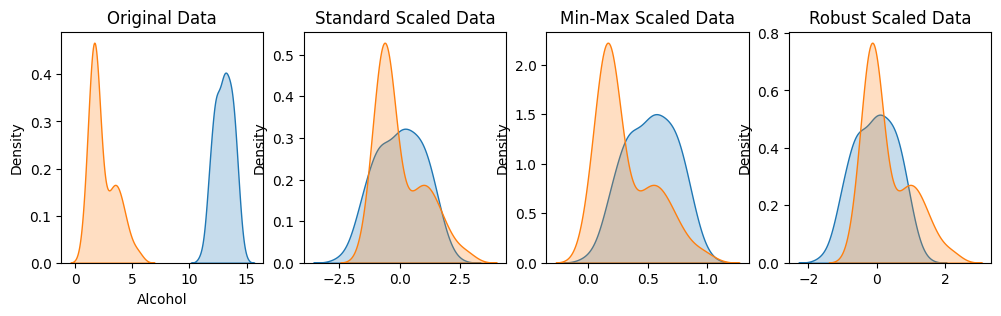

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = train_test_split(data[['Alcohol', 'Malic acid']], data['Class label'], test_size=0.3, random_state=0)

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

rs = RobustScaler()
X_train_rs = rs.fit_transform(X_train)
X_test_rs = rs.transform(X_test)

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
sns.kdeplot(X_train['Alcohol'], ax=ax[0], label='Alcohol', shade=True)
sns.kdeplot(X_train['Malic acid'], ax=ax[0], label='Malic acid', shade=True)
sns.kdeplot(X_train_std[:, 0], ax=ax[1], label='Alcohol', shade=True)
sns.kdeplot(X_train_std[:, 1], ax=ax[1], label='Malic acid', shade=True)
sns.kdeplot(X_train_mm[:, 0], ax=ax[2], label='Alcohol', shade=True)
sns.kdeplot(X_train_mm[:, 1], ax=ax[2], label='Malic acid', shade=True)
sns.kdeplot(X_train_rs[:, 0], ax=ax[3], label='Alcohol', shade=True)
sns.kdeplot(X_train_rs[:, 1], ax=ax[3], label='Malic acid', shade=True)

ax[0].set_title('Original Data')
ax[1].set_title('Standard Scaled Data')
ax[2].set_title('Min-Max Scaled Data')
ax[3].set_title('Robust Scaled Data')
plt.show()


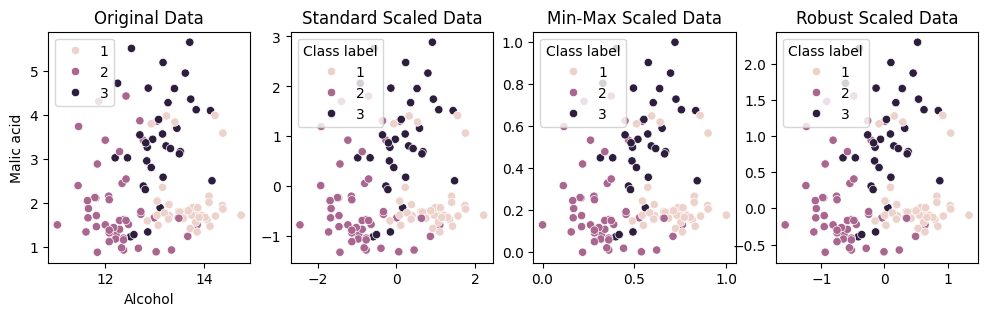

In [41]:
## Scatter plot of original data and scaled data
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
sns.scatterplot(x=X_train['Alcohol'], y=X_train['Malic acid'], hue=y_train, ax=ax[0])
sns.scatterplot(x=X_train_std[:, 0], y=X_train_std[:, 1], hue=y_train, ax=ax[1])
sns.scatterplot(x=X_train_mm[:, 0], y=X_train_mm[:, 1], hue=y_train, ax=ax[2])
sns.scatterplot(x=X_train_rs[:, 0], y=X_train_rs[:, 1], hue=y_train, ax=ax[3])
ax[0].set_title('Original Data')
ax[1].set_title('Standard Scaled Data')
ax[2].set_title('Min-Max Scaled Data')
ax[3].set_title('Robust Scaled Data')
ax[0].legend()
plt.show()